####======================================================
### **Homework Assignment 2**
### Saurav Luthra, 55027009
### **ECE 648 - Machine Learning**

#### ====================================================
#### INTRODUCTION + OVERVIEW
#### ======================================================

This assignment focuses on analyzing vertebral column data from *Vertebral_column_3C.dat* to examine relationships between biomechanical features and the orthopaedic patients' classes (disk hernia, normal, spondilolysthesis). The dataset contains 310 data points (rows) and has 7 features (columns), including the label. The aim is to effectively classify/predict the patient class, as a function of 6 features. To achieve this the sklearn, numpy, pandas, seaborn, and matplotlib packages were used. The following steps were performed:

1. Values for 6 independent variables/features (unnamed) and the class, *label*, were loaded into a DataFrame.

2. Scatter plots were generated to visualize each of the patient classes' relationship with each of the 6 features.

3. A logistic regression model was used to build a multiclass classifier, and its confusion matrix, metrics, and prediction accuracy were displayed.

4. An LDA classifier was built, and its confusion matrix, metrics, and prediction accuracy were displayed.









#### ====================================================
#### IMPORT PACKAGES
#### ======================================================

In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import make_classification
from sklearn.metrics import classification_report, accuracy_score


#### ====================================================
#### LOAD DATA INTO DATAFRAME
#### ======================================================

In [109]:
# create dataframe (df) from the input file
df = pd.read_csv('Vertebral_column_3C.dat', sep = '\s+', header = None)

# display df head
df.head()

,0,1,2,3,4,5,6
0,63.03,22.55,39.61,40.48,98.67,-0.25,DH
1,39.06,10.06,25.02,29.00,114.41,4.56,DH
2,68.83,22.22,50.09,46.61,105.99,-3.53,DH
3,69.30,24.65,44.31,44.64,101.87,11.21,DH
4,49.71,9.65,28.32,40.06,108.17,7.92,DH


In [110]:
# check df dimensions
df.shape

(310, 7)

In [111]:
# check df columns for missing values
df.isnull().sum().to_frame().transpose()

,0,1,2,3,4,5,6
0,0,0,0,0,0,0,0


In [112]:
# make X matrix
X = df.iloc[:, :6].rename(columns = {0: 'f0', 1: 'f1', 2: 'f2', 3: 'f3', 4: 'f4', 5: 'f5'})

X

,f0,f1,f2,f3,f4,f5
0,63.03,22.55,39.61,40.48,98.67,-0.25
1,39.06,10.06,25.02,29.00,114.41,4.56
2,68.83,22.22,50.09,46.61,105.99,-3.53
3,69.30,24.65,44.31,44.64,101.87,11.21
4,49.71,9.65,28.32,40.06,108.17,7.92
...,...,...,...,...,...,...
305,47.90,13.62,36.00,34.29,117.45,-4.25
306,53.94,20.72,29.22,33.22,114.37,-0.42
307,61.45,22.69,46.17,38.75,125.67,-2.71
308,45.25,8.69,41.58,36.56,118.55,0.21


In [113]:
# make y vector and map the labels to integers
# 0 - disk hernia       - DH
# 1 - spondilolysthesis - SL
# 2 - normal            - NO

y = df.iloc[:, 6:].rename(columns={6: 'label'})

mapping = {'DH': 0, 'SL': 1, 'NO': 2}
y['label'] = y['label'].map(mapping)

y

,label
0,0
1,0
2,0
3,0
4,0
...,...
305,2
306,2
307,2
308,2


In [114]:
#split data into a training set (70%) and a testing set (30%)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1, stratify = y)

In [115]:
#standardize features (training and testing dataset)

sc = StandardScaler()
sc.fit(X_train)

X_train = sc.transform(X_train)
X_test = sc.transform(X_test)

#### ====================================================
#### VISUALIZE DATA + FEATURES
#### ======================================================

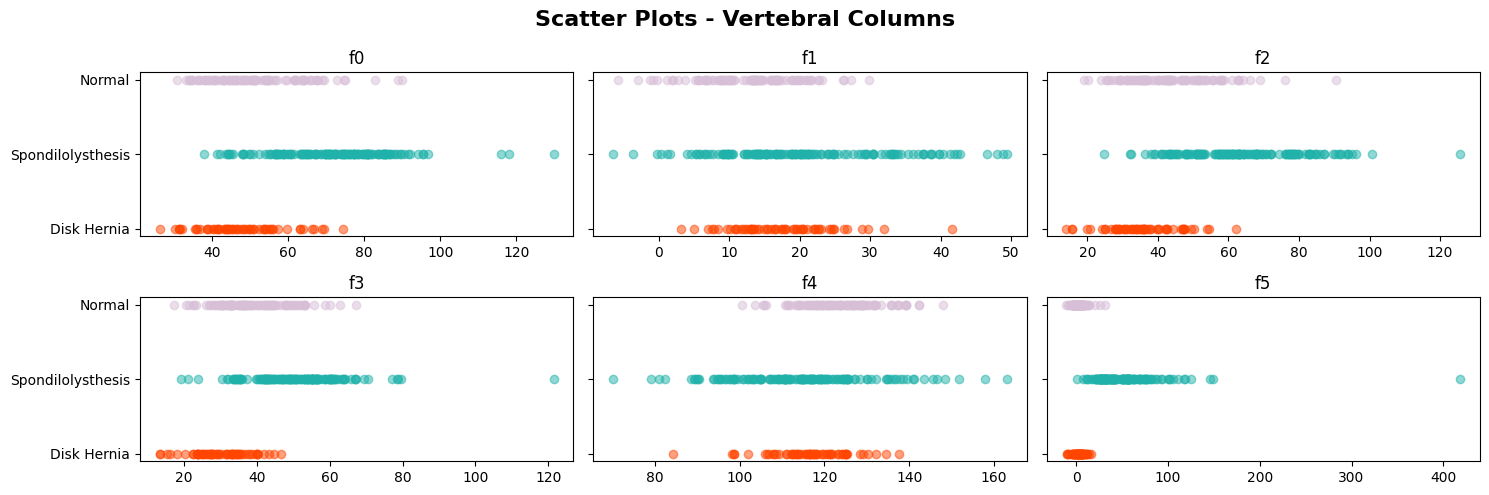

In [116]:
# plot each feature against y
fig, axes = plt.subplots(2, 3, figsize = (15, 5), sharey = True)  # 2 rows, 3 columns
axes = axes.flatten()

# define colors for each label
colors = {0: 'orangered', 1: 'lightseagreen', 2: 'thistle'}

for i, feature in enumerate(X.columns):

    for label in y['label'].unique():

        axes[i].scatter(X[y['label'] == label][feature], y[y['label'] == label], alpha = 0.5, color = colors[label])

    axes[i].set_title(feature)
    axes[i].set_yticks([0, 1, 2])
    axes[i].set_yticklabels(['Disk Hernia', 'Spondilolysthesis', 'Normal'])

# figure title
fig.suptitle("Scatter Plots - Vertebral Columns", fontsize = 16, fontweight = 'bold', ha = 'center', va = 'top')

plt.tight_layout()
plt.show()


#### ====================================================
#### BUILD LOGISTIC REGRESSION MODEL (3 CLASSES)
#### ======================================================

In [117]:
# logistic regression model using sklearn
# build a one versus rest (OVR) logistic regression model for the labels in df (0,1,2)

model_logistic = OneVsRestClassifier(LogisticRegression()).fit(X_train, y_train)

y_pred_logistic = model_logistic.predict(X_test)

#### ====================================================
#### TEST LOGISTIC REGRESSION MODEL
#### ======================================================

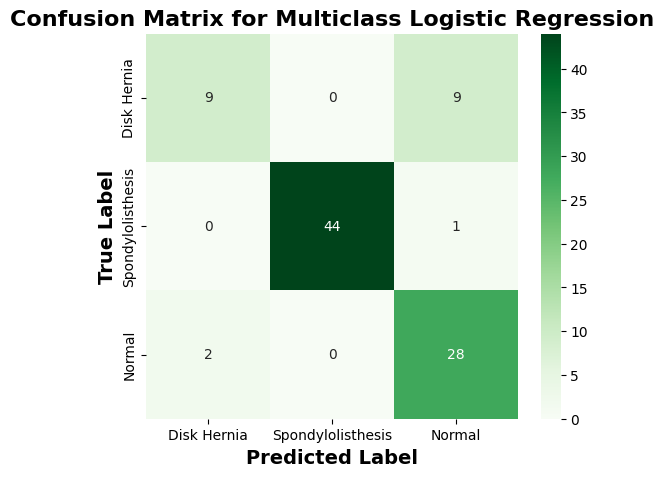

Classification Report:
                    precision    recall  f1-score   support

      Disk Hernia       0.82      0.50      0.62        18
Spondylolisthesis       1.00      0.98      0.99        45
           Normal       0.74      0.93      0.82        30

         accuracy                           0.87        93
        macro avg       0.85      0.80      0.81        93
     weighted avg       0.88      0.87      0.86        93



In [118]:
# generate confusion matrix
cm = confusion_matrix(y_test, y_pred_logistic)

# class label names
class_labels = ["Disk Hernia", "Spondylolisthesis", "Normal"]

# plot confusion matrix
plt.figure(figsize = (6, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Greens', xticklabels = class_labels, yticklabels = class_labels)

plt.xlabel("Predicted Label", fontsize = 14, color = "black", fontweight = "bold")
plt.ylabel("True Label", fontsize = 14, color = "black", fontweight = "bold")
plt.title("Confusion Matrix for Multiclass Logistic Regression", fontsize = 16, color = "black", fontweight = "bold")

plt.show()

# print classification report
print("Classification Report:\n", classification_report(y_test, y_pred_logistic, target_names = class_labels))

In [119]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
print(f"Prediction accuracy: {accuracy_logistic:.2f}")

Prediction accuracy: 0.87


#### ====================================================
#### BUILD LDA CLASSIFIER
#### ======================================================

In [120]:
# create and fit the LDA model
model_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)

# predict the labels on the test set
y_pred_lda = model_lda.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


#### ====================================================
#### TEST LDA CLASSIFIER
#### ======================================================

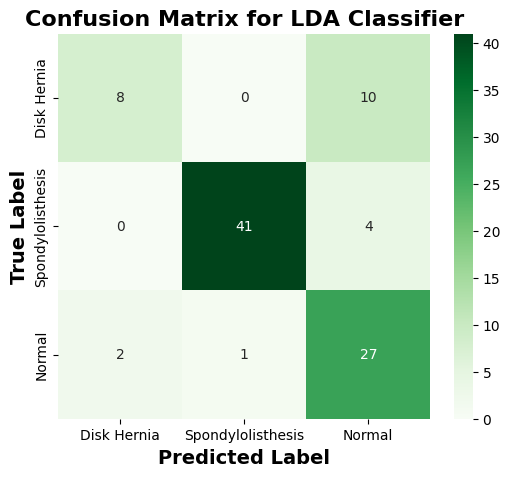

Classification Report:
                    precision    recall  f1-score   support

      Disk Hernia       0.80      0.44      0.57        18
Spondylolisthesis       0.98      0.91      0.94        45
           Normal       0.66      0.90      0.76        30

         accuracy                           0.82        93
        macro avg       0.81      0.75      0.76        93
     weighted avg       0.84      0.82      0.81        93



In [121]:
# generate confusion matrix
cm = confusion_matrix(y_test, y_pred_lda)

# class label names
class_labels = ["Disk Hernia", "Spondylolisthesis", "Normal"]

# plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Greens', xticklabels = class_labels, yticklabels = class_labels)

plt.xlabel("Predicted Label", fontsize=14, color="black", fontweight="bold")
plt.ylabel("True Label", fontsize=14, color="black", fontweight="bold")
plt.title("Confusion Matrix for LDA Classifier", fontsize=16, color="black", fontweight="bold")

plt.show()

# print classification report
print("Classification Report:\n", classification_report(y_test, y_pred_lda, target_names = class_labels))

In [122]:
# print the accuracy score

accuracy_lda = accuracy_score(y_test, y_pred_lda)
print(f"Prediction accuracy: {accuracy_lda:.2f}")

Prediction accuracy: 0.82


#### ====================================================
#### CONCLUSION + DISCUSSION
#### ======================================================

____________________________________________________________

**Logistic Regression Classifier:**

Prediction Accuracy: 0.87
____________________________________________________________

**Linear Discriminant Analysis (LDA) Classifer:**

Prediction Accuracy: 0.82
____________________________________________________________

Both the Logistic Regression Classifier and the LDA classifier showed good results and prediction accuracy. Both models were trained on standardized data (to account for variations in the magnitude of features), which had the effect of slightly improving the prediction accuracy. The confusion matrices do a good job illustrating the results of the predictions for both the models. Both of the models do an excellent job correctly predicting the "Spondylolisthesis" and "Normal" labels, however, did a poor job at "Disk Hernia", where it was very often predicted as "Normal".